In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Import the simulated airfoil data
df = pd.read_csv("../data/airfoil_data.csv")
pd.set_option("display.max_columns", None)

In [4]:
# Function to plot probability of convergence for given values of chosen airfoil parameter
def plot_mean(df,x,y,ylim=None):
    prob = df.groupby(x, observed=True)[y].mean()
    plt.plot(prob.index, prob, "o-")
    plt.grid()
    plt.xlabel(x)
    plt.ylabel(f"mean of {y}")
    if ylim is not None:
        plt.ylim = ylim
    plt.show()

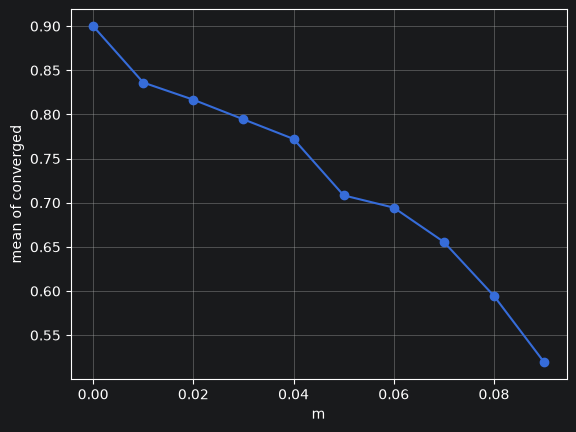

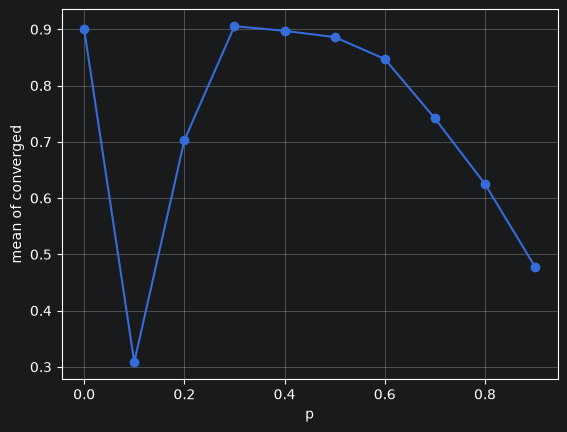

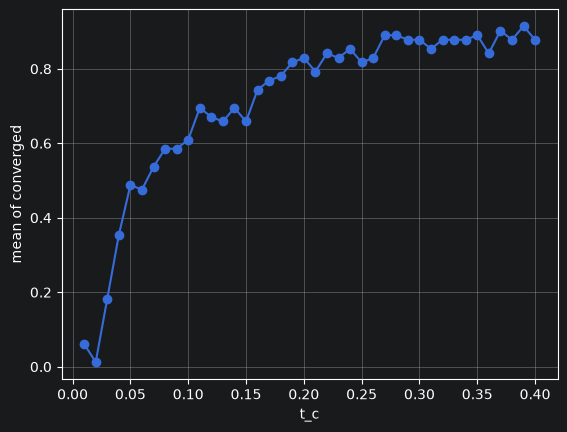

In [5]:
plot_mean(df,x="m",y="converged",ylim=(0,1))
plot_mean(df,x="p",y="converged",ylim=(0,1))
plot_mean(df,x="t_c",y="converged",ylim=(0,1))

Observations:
- Convergence steadily decreases with camber
- Influence of the position of max. camber shows a strange behavior at between p=0 and p=0.3
- Convergence increases for larger thicknesses up to a limit of about 90%

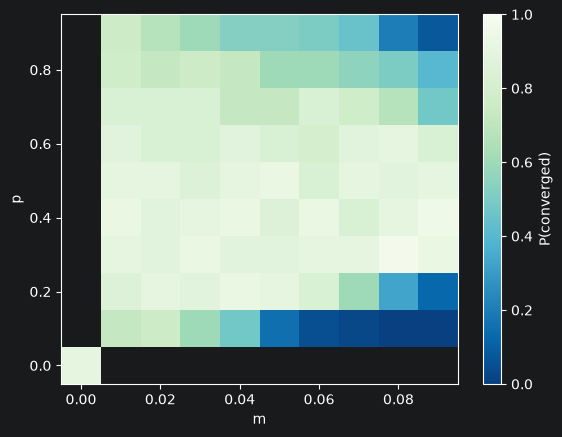

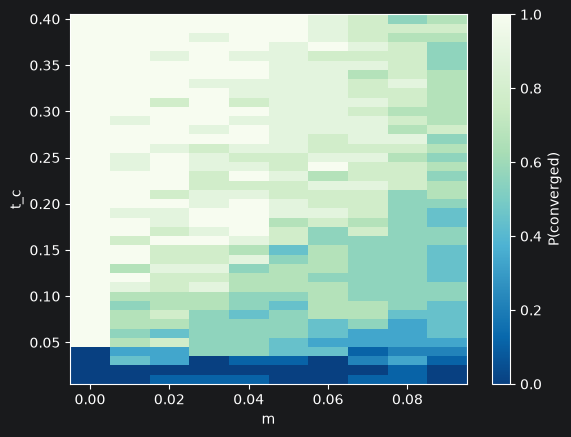

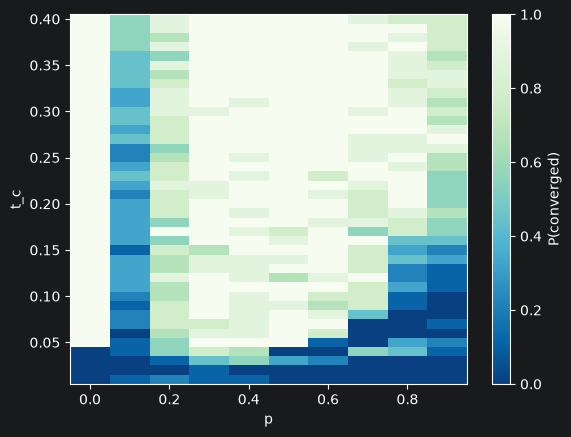

In [6]:
def plot_convergence_heatmap(df, x1, x2):
    probability = df.pivot_table(
        index=x2,
        columns=x1,
        values="converged",
        aggfunc="mean"
    )

    plt.pcolormesh(
        probability.columns,
        probability.index,
        probability,
        cmap="GnBu_r",
        vmin=0,
        vmax=1,
        shading="nearest"
    )

    plt.xlabel(x1)
    plt.ylabel(x2)
    plt.colorbar(label="P(converged)")
    plt.show()

plot_convergence_heatmap(df, "m", "p")
plot_convergence_heatmap(df,'m','t_c')
plot_convergence_heatmap(df,'p','t_c')

Observations:
- Cases do not converge for large camber near nose and tail (large m with large and small p)
- Convergence is generally poor for small thicknesses
- Strange low convergence for p=0.1 across all values of thickness
- Convergence first improves with more aft position of max. camber (higher values of p) after the very low value at p=0.1, but eventually drops again

Note:
- There is only one observation for p=0, because for this case, changing m does not result in different geometry
- Also varying p for m=0 does not make sense because the max camber point is at the LE

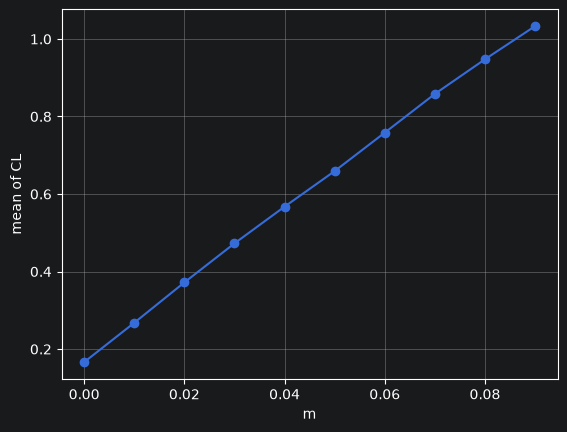

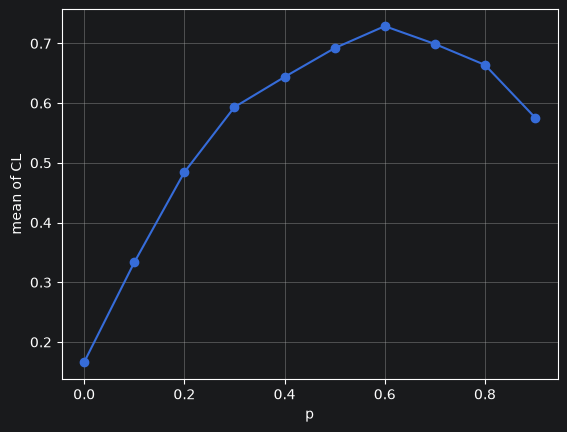

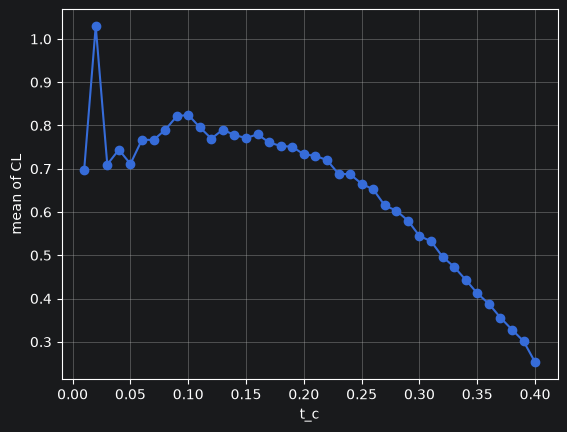

In [7]:
plot_mean(df,x='m',y='CL')
plot_mean(df,x='p',y='CL')
plot_mean(df,x='t_c',y='CL')

In [8]:
mean_cl = df.groupby("t_c")["CL"].mean()
t_c_spike = mean_cl.idxmax()
cl_spike = mean_cl.max()
print(f" Max. average CL at t_c = {t_c_spike} with value CL = {cl_spike}")

 Max. average CL at t_c = 0.02 with value CL = 1.0296


Observations - When averaging over the other geometrical parameters among converged cases, for given AoA and Re:
- CL increases linearly with camber
- CL increases with more aft position of max. camber up to a limit after which CL decreases again
- CL seems to initially increase with t/c up to about 0.1 after which it decreases again - effect of missing unconverged cases can be significant at low thicknesses
- Strange spike in CL is present for t/c= 0.02

In [9]:
df.loc[
    (df["t_c"] == 0.02) & df["converged"],
    ["naca", "m", "p", "CL", "converged"]
]

,naca,m,p,CL,converged
2641,8302,0.08,0.3,1.0296,True


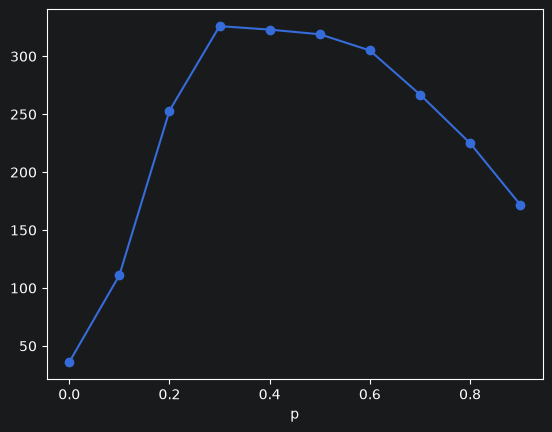

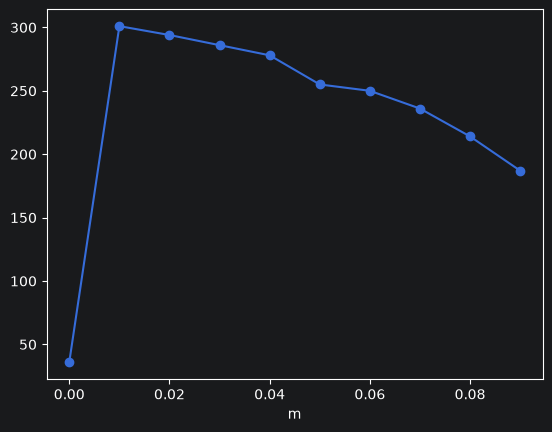

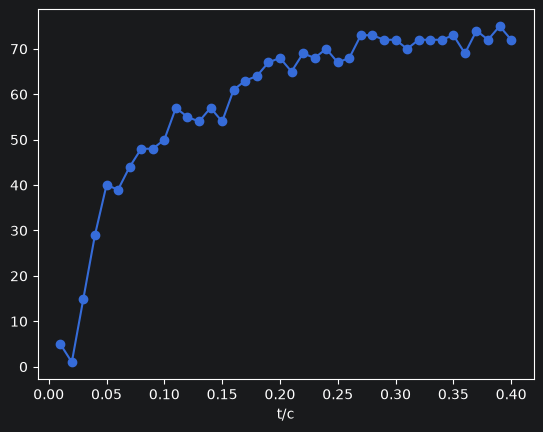

In [10]:
plt.plot(df[df["converged"]].groupby("p").size(),marker="o")
plt.xlabel("Number of converged cases")
plt.xlabel("p")
plt.show()

plt.plot(df[df["converged"]].groupby("m").size(),marker="o")
plt.xlabel("Number of converged cases")
plt.xlabel("m")
plt.show()

plt.plot(df[df["converged"]].groupby("t_c").size(),marker="o")
plt.xlabel("Number of converged cases")
plt.xlabel("t/c")
plt.show()

In [11]:
df[df["converged"]].groupby("p").size()

p
0.0     36
0.1    111
0.2    253
0.3    326
0.4    323
0.5    319
0.6    305
0.7    267
0.8    225
0.9    172
dtype: int64

Observations:
- Overall, 2337 of 3280 cases converged (~71%).
- Convergence probability generally decreases as camber \(m\) increases.
- Convergence is very poor for thin airfoils and improves strongly with increasing \(t/c\), eventually reaching roughly 85–90%.
- Camber position \(p\) has a nonlinear relationship with convergence. Convergence is particularly poor at \(p=0.1\), is highest for intermediate values of \(p\), and decreases again as the maximum camber moves farther aft.
- The heatmaps indicate interactions between the geometric parameters. In particular, large camber combined with very forward or very aft camber position produces poor convergence. Higher-camber airfoils also appear to require greater thickness for reliable convergence.
- The poor convergence at \(p=0.1\) is not caused by a smaller number of attempted cases. 111 of 360 cases converge at \(p=0.1\), giving \(P(\text{converged})\approx0.31\). In comparison, 36 of the 40 symmetric (\(p=0\)) cases converge.
- Very few extremely thin airfoils converge: only 5 cases at \(t/c=0.01\) and 1 case at \(t/c=0.02\). Consequently, aerodynamic statistics calculated from the converged cases at these thicknesses are not representative of the full geometric design space.
- XFOIL convergence failures are therefore not randomly distributed throughout the design space. Subsequent analysis of aerodynamic coefficients uses a geometry-dependent subset of the originally generated airfoils.

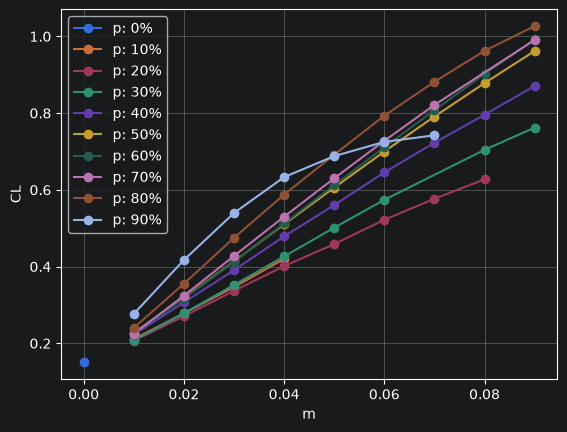

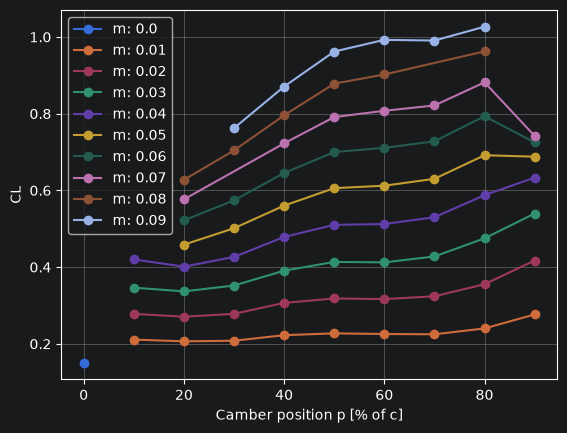

In [12]:
for p in df['p'].unique():
    df_plot = df[(df['t_c']==0.3) & (df['converged']) & (df['p']==p)]
    plt.plot(df_plot['m'],df_plot['CL'],marker="o",label=f'p: {int(p*100)}%')
plt.legend()
plt.xlabel("m")
plt.ylabel("CL")
plt.grid()
plt.show()

for m in df['m'].unique():
    df_plot = df[(df['t_c']==0.3) & (df['converged']) & (df['m']==m)]
    plt.plot(df_plot['p']*100,df_plot['CL'],marker="o",label=f'm: {m}')
plt.legend()
plt.xlabel("Camber position p [% of c]")
plt.ylabel("CL")
plt.grid()
plt.show()

Observations:
- When other parameters are held constant, CL seems to increase linearly with m, except for the case where the max camber is at 90% of the chord
- Slope of CL as function of m seems to increase with increasing value of p
- The influence of camber position (p) seems to increase with larger values of camber (m) as expected. The relationship is not perfectly linear
- Region of high m and high p is missing data points due to failed convergence

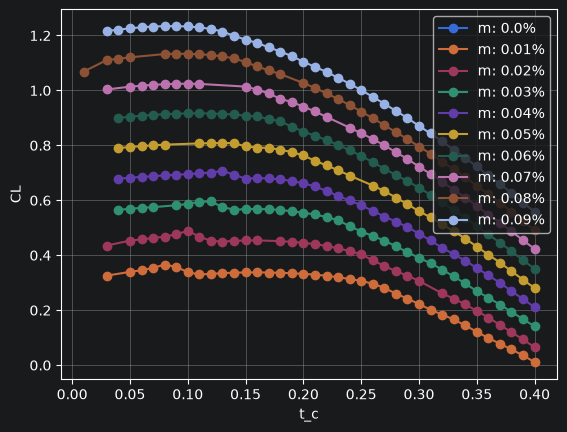

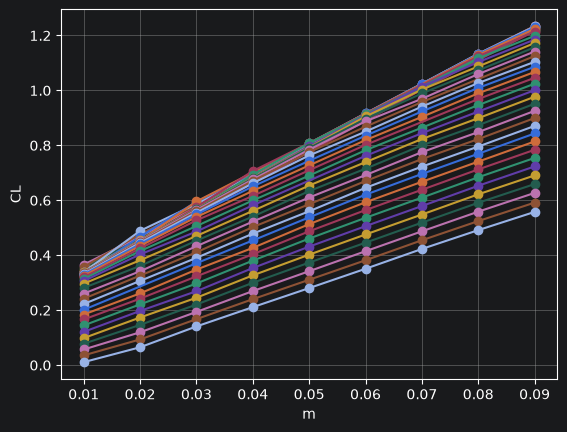

In [13]:
for m in df['m'].unique():
    df_plot = df[(df['p']==0.4) & (df['converged']) & (df['m']==m)]
    plt.plot(df_plot['t_c'],df_plot['CL'],marker="o",label=f'm: {m}%')
plt.legend(loc="upper right")
plt.xlabel("t_c")
plt.ylabel("CL")
plt.grid()
plt.show()

for t_c in df['t_c'].unique():
    df_plot = df[(df['p']==0.4) & (df['converged']) & (df['t_c']==t_c)]
    plt.plot(df_plot['m'],df_plot['CL'],marker="o",label=f't_c: {t_c}')
plt.xlabel("m")
plt.ylabel("CL")
plt.grid()
plt.show()

Observations:
- When other parameters are held constant, CL varies non-linearly with thickness, showing maximum at lower thicknesses and dropping off for larger thicknesses
- Both intercept and shape of the CL vs. thickness curve seem to vary with camber, with the variation in position being more pronounced
- When other parameters are held constant, CL seems to vary linearly with camber, with both slope and intercept varying slightly with thickness

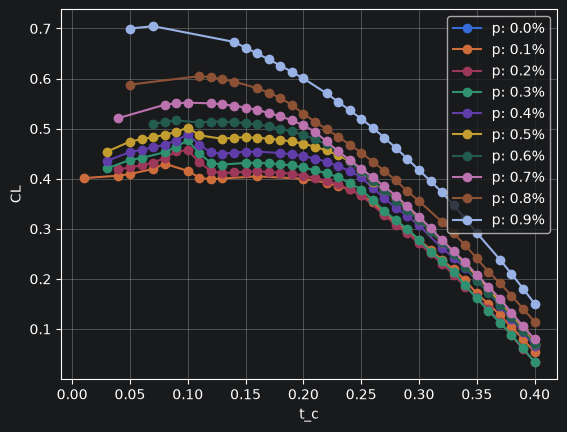

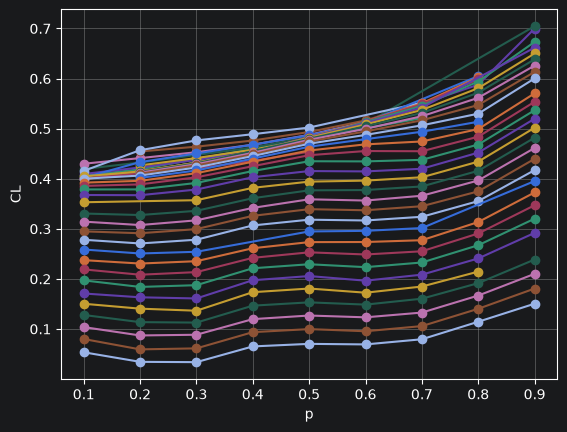

In [14]:
for p in df['p'].unique():
    df_plot = df[(df['m']==0.02) & (df['converged']) & (df['p']==p)]
    plt.plot(df_plot['t_c'],df_plot['CL'],marker="o",label=f'p: {p}%')
plt.legend(loc="upper right")
plt.xlabel("t_c")
plt.ylabel("CL")
plt.grid()
plt.show()

for t_c in df['t_c'].unique():
    df_plot = df[(df['m']==0.02) & (df['converged']) & (df['t_c']==t_c)]
    plt.plot(df_plot['p'],df_plot['CL'],marker="o",label=f't_c: {t_c}')
plt.xlabel("p")
plt.ylabel("CL")
plt.grid()
plt.show()

Observations:
- When other parameters are held fixed, CL against shows the same non-linear behavior with thickness and only modest effect of p on the slope
- When other parameters are held fixed, CL against shows quite weak non-linear variation with p, with the slope varying only slightly with thickness

Summary:
- CL varies approximately linearly with m
- CL varies non-linearly with p
- CL varies strongly non-linearly with thickness
- Strong interaction is indicated between m and p
- Only weaker interactions are indicated between m and thickness and between p and thickness

In [15]:
df[df["converged"] & (df["p"] > 0)].groupby("p").agg(
    mean_CL=("CL", "mean"),
    mean_m=("m", "mean"),
    count=("CL", "size")
)

,mean_CL,mean_m,count
p,,,
0.1,0.333231,0.025766,111
0.2,0.484295,0.041660,253
0.3,0.593341,0.050460,326
0.4,0.643798,0.050031,323
0.5,0.692038,0.049937,319
0.6,0.728866,0.050066,305
0.7,0.699048,0.047228,267
0.8,0.663936,0.045200,225
0.9,0.575845,0.039651,172


In [16]:
df_subset = df[df["converged"] & df["p"].isin([0.6, 0.9])]

matched = df_subset.pivot_table(index=["m", "t_c"],columns="p",values="CL")

matched = matched.dropna()
matched["delta_CL"] = matched[0.9] - matched[0.6]

print(matched["delta_CL"].describe())
print("Positive differences:", (matched["delta_CL"] > 0).sum())
print("Matched geometries:", len(matched))


count    168.000000
mean       0.043514
std        0.094315
min       -0.283000
25%        0.013175
50%        0.077500
75%        0.106475
max        0.195000
Name: delta_CL, dtype: float64
Positive differences: 131
Matched geometries: 168


Note:
- From the made observations it can be concluded that the mean CL curve w.r.t. the max. camber position p struggles from convergence-related selection bias
- Since cases of high m and high p are more likely to diverge and since high m in general leads to higher CL, the average CL curve artificially drops for high values of p
- Simpson's paradox - Where an aggregated relationship can differ from the relationships observed within individual groups.

AI explanation:
Marginal versus conditional relationships
The marginal mean \(C_L\) decreases between \(p=0.6\) and \(p=0.9\), suggesting that moving maximum camber farther aft reduces lift.
However, a matched comparison holding \(m\) and \(t/c\) constant gives the opposite result. Among 168 geometries converging at both positions, 131 (78%) exhibit increasing \(C_L\), with an average change of \(+0.0435\).
This reversal demonstrates that marginal averages can obscure the underlying relationship when the composition of observations changes. In this dataset, geometry-dependent XFOIL convergence is a plausible contributor to that change in composition.
Consequently, the effects of individual geometric parameters should be investigated while accounting for the other predictors.